# 1. INTRODUCTION

Single-cell RNA sequencing (scRNA-seq) is a powerful technology that enables the measurement of gene expression at the level of individual cells. Unlike bulk RNA sequencing, which provides an average signal across many cells, scRNA-seq allows the exploration of cellular heterogeneity within a population, even when cells are genetically identical.

Cellular gene expression is strongly influenced by environmental conditions. Changes in nutrient availability or exposure to chemical compounds can induce significant transcriptional responses, leading to distinct cellular states. In yeast, for instance, treatments with compounds such as mycophenolic acid (MPA) and guanine have been shown to produce clearly distinguishable transcriptomic profiles at the single-cell level .

Despite its power, gene-level analysis presents important challenges. Gene expression datasets are typically high-dimensional, sparse, and noisy, making direct interpretation difficult. Moreover, focusing on individual genes may obscure the coordinated activity of groups of genes involved in the same biological processes.

To overcome these limitations, gene expression can be aggregated into functional categories such as biological pathways. This approach reduces dimensionality and provides a more interpretable representation of cellular states, capturing the activity of underlying biological processes rather than individual gene fluctuations.

In this project, I analyze single-cell transcriptomics data by integrating gene expression profiles with external functional annotations. SpecIically, I construct pathway-level representations of each cell and use these features to classify cells according to their growth conditions. This allows not only to build predictive models, but also to gain biological insights into the functional differences between environmental conditions.

# 2. AIM OF THE PROJECT

The aim of this project is to classify single cells according to their growth conditions using pathway-level features derived from gene expression data.

To achieve this, I first transform gene-level expression profiles into a functional representation by grouping genes into biological pathways using external annotation resources. This allows me to obtain a more interpretable and biologically meaningful description of each cell.

I then train classification models to predict the growth medium of each cell based on these pathway-level features. The performance of the models is evaluated using metrics such as accuracy, precision, recall, and F1 score, as well as cross-validation techniques.

Finally, I analyze the importance of different pathways in the classification process in order to identify the key biological functions that distinguish cells grown in different conditions.


# 3. IMPLEMENTATION

## 3.1 Dataset

The dataset used in this project is derived from the GEO accession GSE165686 and originates from a study investigating the effects of mycophenolic acid (MPA) and guanine on gene expression in *Saccharomyces cerevisiae* at the single-cell level .

In this experiment, yeast cells were grown under four different conditions:

* DMSO (control)
* Guanine (G)
* Mycophenolic acid (MPA)
* MPA + Guanine (MG)

Each condition induces a distinct transcriptional response, resulting in different gene expression profiles across cells. Previous analysis of this dataset has shown that cells cluster according to their growth conditions, indicating that each medium produces a specific transcriptomic signature .

The data are provided in Matrix Market format and consist of:

* A sparse matrix containing gene expression counts (genes × cells)
* A list of genes (features)
* A list of cell barcodes
* A metadata table containing the experimental condition

In this project, the experimental condition associated with each cell is used as the target variable for the classification task.

## 3.2 Data Preprocessing

In this section, I load and preprocess the single-cell RNA sequencing data. The goal is to construct a clean and usable data structure that will be used for downstream analyses, including pathway aggregation and classification.


In [6]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

#### 3.2.1 Data Loading and Structure Setup

In [8]:
adata = sc.read_mtx("../data/raw/GSE165686_yeastdropseq_dge.mtx.gz")
genes = pd.read_csv("../data/raw/GSE165686_features.tsv.gz", sep="\t", header=None)
barcodes = pd.read_csv("../data/raw/GSE165686_barcodes.tsv.gz", sep="\t", header=None)
metadata = pd.read_csv("../data/raw/GSE165686_metadata.tsv.gz", sep="\t")

In [9]:
print(adata)
adata.shape

AnnData object with n_obs × n_vars = 4777 × 844


(4777, 844)

In [10]:
print(genes.head())
print(barcodes.head())

     0       1
0  NaN       x
1  1.0    LSR1
2  2.0  RDN5-1
3  3.0   RUF20
4  4.0    TLC1
     0             1
0  NaN             x
1  1.0  AAAAGATTATGA
2  2.0  AAACAAAGAGGA
3  3.0  AAAGCCTATGTA
4  4.0  AAAGTTCCTTCG


In [11]:
#remove first row
genes = genes.iloc[1:]
barcodes = barcodes.iloc[1:]

In [12]:
#extract genes names
gene_names = genes.iloc[:, 1].values
cell_names = barcodes.iloc[:, 1].values

In [13]:
print(len(gene_names), adata.n_vars)
print(len(cell_names), adata.n_obs)

4777 844
844 4777


In [14]:
# the original matrix is organized as genes x cells
# AnnData requires cells as observations (rows) and genes as variables (columns)
# therefore transpose the matrix
adata = adata.T

In [15]:
print(len(gene_names), adata.n_vars)
print(len(cell_names), adata.n_obs)
adata.shape

4777 4777
844 844


(844, 4777)

In [16]:
#Gene names and cell barcodes assigned to the AnnData object as variable names and observation names 
adata.var_names = gene_names
adata.obs_names = cell_names

In [81]:
#metadata inspection
metadata.head()

,sample,sc3_8_clusters,sc3_4_clusters,PC_1,PC_2,PC_3,UMAP_1,UMAP_2
barcode,,,,,,,,
AAAAGATTATGA,DMSO,DMSO.1,3,6.527174,-7.677352,-6.994669,2.212932,3.913240
AAACAAAGAGGA,DMSO,DMSO.1,1,-3.163107,-3.880306,2.174751,1.483353,-1.860849
AAAGCCTATGTA,DMSO,DMSO.1,1,-5.735034,-2.363518,2.823618,1.619440,-2.293614
AAAGTTCCTTCG,DMSO,DMSO.1,3,5.783699,-7.457446,-5.531393,2.187911,3.793437
AAATGACTTCAC,DMSO,DMSO.2,2,3.542129,-3.103941,-8.892211,2.094342,4.569191


In [18]:
metadata = metadata.rename(columns={"Unnamed: 0": "barcode"})
#set cell name as index 
metadata = metadata.set_index("barcode")

In [19]:
#matching inspection
print(adata.obs_names[:5])
print(metadata.index[:5])

Index(['AAAAGATTATGA', 'AAACAAAGAGGA', 'AAAGCCTATGTA', 'AAAGTTCCTTCG',
       'AAATGACTTCAC'],
      dtype='object')
Index(['AAAAGATTATGA', 'AAACAAAGAGGA', 'AAAGCCTATGTA', 'AAAGTTCCTTCG',
       'AAATGACTTCAC'],
      dtype='object', name='barcode')


In [20]:
# Assign experimental condition (label) to each cell 
adata.obs["condition"] = metadata.loc[adata.obs_names, "sample"]

#### 3.2.2 Data Inspection

In [22]:
total_counts_per_cell = np.sum(adata.X, axis=1)
total_counts_per_cell[:10]

matrix([[2643.],
        [ 538.],
        [ 511.],
        [1676.],
        [1538.],
        [ 722.],
        [1850.],
        [ 909.],
        [ 978.],
        [ 943.]], dtype=float32)

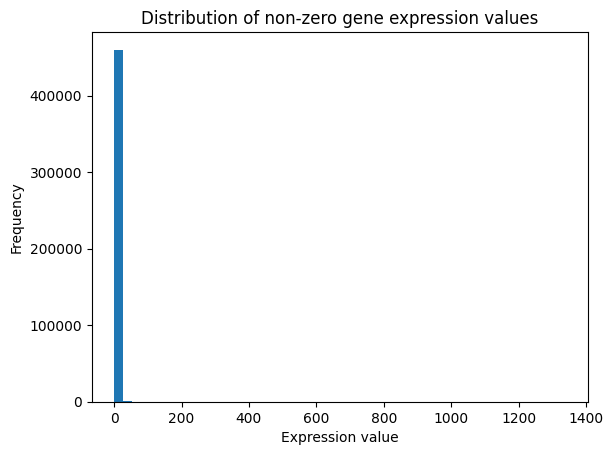

In [23]:
#distribution of gene expression values across all cells and genes

# Convert sparse matrix to dense array for visualization
values = adata.X.toarray().flatten()

# Remove zeros only for visualization purposes
values_nz = values[values > 0]

# Plot histogram
plt.hist(values_nz, bins=50)
plt.title("Distribution of non-zero gene expression values")
plt.xlabel("Expression value")
plt.ylabel("Frequency")
plt.show()

The distribution of gene expression values is highly skewed. Most genes show low expression levels, while a small number of genes exhibit very high expression values. 

To improve visualization, zero values were excluded, as they dominate the dataset and obscure the variability of expressed genes. However, zero values were retained in the dataset, as they represent biologically meaningful absence of expression.

Even after removing zeros, the distribution remains strongly skewed. Therefore, a log transformation is applied to compress large values and obtain a more balanced distribution. 


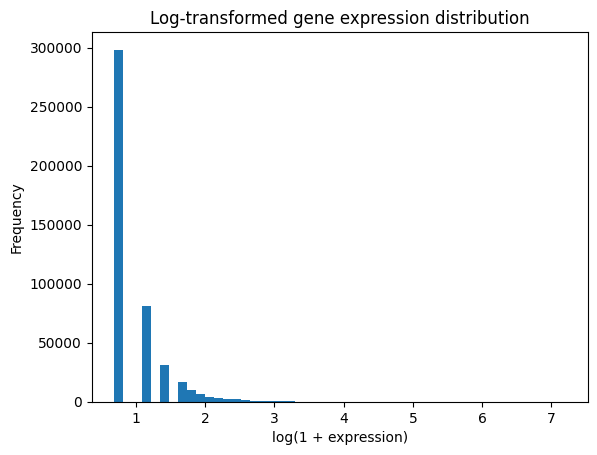

In [25]:
# Apply log transformation to reduce skewness and stabilize variance
values_log = np.log1p(values_nz)

plt.hist(values_log, bins=50)
plt.title("Log-transformed gene expression distribution")
plt.xlabel("log(1 + expression)")
plt.ylabel("Frequency")
plt.show()

After applying log transformation, the distribution of gene expression values becomes more balanced and less skewed. High-expression outliers are compressed, making the overall distribution more suitable for downstream analyses such as pathway aggregation and classification.


#### 3.2.3 Normalization and Log Transformation

In [28]:
# Normalize counts per cell (library size normalization)
sc.pp.normalize_total(adata, target_sum=1e4)

In [29]:
# Check total counts per cell after normalization
total_counts = adata.X.sum(axis=1)
total_counts[:10]

matrix([[10000.   ],
        [ 9999.999],
        [10000.   ],
        [ 9999.999],
        [10000.   ],
        [10000.   ],
        [10000.   ],
        [10000.001],
        [10000.   ],
        [10000.001]], dtype=float32)

In [30]:
#apply log transformation to reduce skewness and stabilize variance
sc.pp.log1p(adata)

In [31]:
# Inspect transformed values
adata.X[:5, :5].toarray()

array([[0.       , 0.       , 1.5651891, 1.5651891, 0.       ],
       [0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.       , 0.       ],
       [1.9411254, 0.       , 0.       , 0.       , 1.9411254],
       [0.       , 0.       , 0.       , 0.       , 0.       ]],
      dtype=float32)

### 3.3 Functional Annotation

To map genes to biological pathways, KEGG functional annotations were used. The KEGG BRITE hierarchy provides a structured representation of metabolic pathways and their associated genes.

The downloaded file (htext format) contains hierarchical information, where pathways and genes are organized using different levels. This file is parsed to extract gene-to-pathway relationships.


In [33]:
# Load KEGG file
kegg_file = "../data/raw/sce00001.keg"
# Read KEGG htext file line by line
with open(kegg_file, "r") as f:
    kegg_lines = f.readlines()

The KEGG file is organized as a hierarchical structure. Lines starting with "C" represent pathways, while lines starting with "D" correspond to genes belonging to those pathways. This structure allows the extraction of gene-to-pathway relationships.


In [35]:
# Show first lines of KEGG file
#to inspect structure (hierarchical levels: A, B, C, D)
kegg_lines[:20]

['+D\tGENES\tKO\n',
 '#<h2><a href="/kegg/brite.html"><img src="/Fig/bget/kegg3.gif" align="middle" border=0></a> &nbsp; KEGG Orthology (KO) - Saccharomyces cerevisiae (budding yeast) </h2>\n',
 '%<!-- w=600, -->\n',
 '!\n',
 'A09100 Metabolism\n',
 'B\n',
 'B  09101 Carbohydrate metabolism\n',
 'C    00010 Glycolysis / Gluconeogenesis [PATH:sce00010]\n',
 'D      YCL040W GLK1; glucokinase\tK00844 HK; hexokinase [EC:2.7.1.1]\n',
 'D      YDR516C EMI2; putative glucokinase\tK00844 HK; hexokinase [EC:2.7.1.1]\n',
 'D      YFR053C HXK1; hexokinase 1\tK00844 HK; hexokinase [EC:2.7.1.1]\n',
 'D      YGL253W HXK2; hexokinase 2\tK00844 HK; hexokinase [EC:2.7.1.1]\n',
 'D      YLR446W NGK1; hexokinase\tK00844 HK; hexokinase [EC:2.7.1.1]\n',
 'D      YBR196C PGI1; glucose-6-phosphate isomerase\tK01810 GPI; glucose-6-phosphate isomerase [EC:5.3.1.9]\n',
 'D      YGR240C PFK1; 6-phosphofructokinase subunit alpha\tK00850 pfkA; 6-phosphofructokinase 1 [EC:2.7.1.11]\n',
 'D      YMR205C PFK2; 6-phos

In [36]:
adata.var_names[:10]

Index(['LSR1', 'RDN5-1', 'RUF20', 'TLC1', 'YAL001C', 'YAL002W', 'YAL003W',
       'YAL005C', 'YAL007C', 'YAL008W'],
      dtype='object')

Both gene identifiers and gene names were considered when matching KEGG annotations to the dataset, in order to maximize coverage and avoid excluding relevant genes due to naming differences.


In [38]:
# Initialize dictionary to store pathway → genes
pathway_dict = {}

current_pathway = None

In [39]:
#parsing KEGG lines
for line in kegg_lines:
    
    line = line.strip()
    
    if line.startswith("C"):
    
    # Remove "c"
        pathway_name = line[1:].strip()
    
    # Rimove code
        pathway_name = pathway_name.split(None, 1)[1]
    
    # Rimove path
        pathway_name = pathway_name.split(" [")[0]
    
        pathway_dict[pathway_name] = []
        current_pathway = pathway_name

    
    # If gene line
    elif line.startswith("D") and current_pathway is not None:
        
        parts = line.split()
        
        # Extract gene ID and gene name
        gene_id = parts[1]
        gene_name = parts[2].replace(";", "")
        
        # Check if gene is in dataset (ID or name)
        if gene_id in adata.var_names or gene_name in adata.var_names:
            pathway_dict[current_pathway].append(gene_id)

In [40]:
#number of pathway
len(pathway_dict)

562

In [41]:
# Check example pathway
list(pathway_dict.items())[:3]

[('Glycolysis / Gluconeogenesis',
  ['YCL040W',
   'YDR516C',
   'YFR053C',
   'YGL253W',
   'YLR446W',
   'YBR196C',
   'YGR240C',
   'YMR205C',
   'YKL060C',
   'YDR050C',
   'YGR192C',
   'YJL052W',
   'YJR009C',
   'YCR012W',
   'YKL152C',
   'YOL056W',
   'YGR254W',
   'YHR174W',
   'YAL038W',
   'YER178W',
   'YBR221C',
   'YNL071W',
   'YFL018C',
   'YDL080C',
   'YGR087C',
   'YLR044C',
   'YLR134W',
   'YDL168W',
   'YBR145W',
   'YMR083W',
   'YMR303C',
   'YOL086C',
   'YGL256W',
   'YCR105W',
   'YMR318C',
   'YER073W',
   'YMR110C',
   'YMR169C',
   'YMR170C',
   'YOR374W',
   'YPL061W',
   'YAL054C',
   'YLR153C',
   'YMR105C',
   'YMR099C',
   'YKR097W']),
 ('Citrate cycle (TCA cycle)',
  ['YCR005C',
   'YNR001C',
   'YPR001W',
   'YLR304C',
   'YDL066W',
   'YNL009W',
   'YNL037C',
   'YOR136W',
   'YIL125W',
   'YDR148C',
   'YFL018C',
   'YOR142W',
   'YGR244C',
   'YLL041C',
   'YKL141W',
   'YLR164W',
   'YPL262W',
   'YDL078C',
   'YKL085W',
   'YOL126C',
   'YBR21

In [42]:
# Check how many genes per pathway
import numpy as np

gene_counts = [len(genes) for genes in pathway_dict.values()]
np.mean(gene_counts), np.min(gene_counts), np.max(gene_counts)

(11.47508896797153, 0, 424)

Pathways with no genes present in the dataset were identified and removed. These pathways do not contribute to downstream analyses and would otherwise introduce noise in the feature matrix.


In [44]:
# Count pathways with 0 genes
zero_gene_pathways = [k for k, v in pathway_dict.items() if len(v) == 0]

len(zero_gene_pathways)

371

In [45]:
# Remove empty pathways
pathway_dict = {k: v for k, v in pathway_dict.items() if len(v) > 0}

In [46]:
len(pathway_dict)

191

In [47]:

min(len(v) for v in pathway_dict.values())

1

Out of the initial set of pathways, 371 had no associated genes and were excluded. The final dataset retained 191 pathways with at least one gene, ensuring meaningful contribution to downstream analyses.


### 3.4 Pathway Feature Construction


Pathway-level features were constructed by aggregating gene expression values for each pathway. For each cell, the mean expression of genes belonging to a given pathway was computed, resulting in a reduced and biologically interpretable feature matrix.


In [84]:
# Create mapping from gene name to column index in expression matrix
gene_to_idx = {gene: i for i, gene in enumerate(adata.var_names)}

In [117]:


# Initialize list to store pathway features
pathway_features = []
pathway_names = []

for pathway, genes in pathway_dict.items():
    
    # Get indices of genes present in dataset
    indices = [gene_to_idx[g] for g in genes if g in gene_to_idx]
    
    # Skip if no valid genes
    if len(indices) == 0:
        continue
    
    # Extract expression values (cells × genes in pathway)
    expr = adata.X[:, indices]
    
    # Compute mean expression per cell
    pathway_mean = np.array(expr.mean(axis=1)).flatten()
    
    # Store results
    pathway_features.append(pathway_mean)
    pathway_names.append(pathway)

The pathway-level features were combined into a matrix and transposed to obtain a cells-by-pathways representation. This matrix was converted into a DataFrame to facilitate interpretation and downstream machine learning analysis.


In [119]:
# Convert list to matrix (pathways × cells)
pathway_matrix = np.vstack(pathway_features)
# Transpose to get (cells × pathways)
pathway_matrix = pathway_matrix.T


In [121]:
pathway_matrix.shape

(844, 190)

In [123]:
# Create DataFrame
pathway_df = pd.DataFrame(
    pathway_matrix,
    index=adata.obs_names,
    columns=pathway_names
)

In [128]:
pathway_df.shape

(844, 190)

In [126]:

pathway_df.head()

,Glycolysis / Gluconeogenesis,Citrate cycle (TCA cycle),Pentose phosphate pathway,Pentose and glucuronate interconversions,Fructose and mannose metabolism,Galactose metabolism,Ascorbate and aldarate metabolism,Starch and sucrose metabolism,Pyruvate metabolism,Glyoxylate and dicarboxylate metabolism,...,Lipid metabolism,Amino acid metabolism,Cofactor metabolism,Transcription,Translation,Transport,Signaling proteins,Structural proteins,General function prediction only,Function unknown
AAAAGATTATGA,1.033856,0.502706,0.745943,0.620877,0.987457,0.130432,0.733776,0.217081,0.595658,0.398955,...,0.000000,0.0,0.0,0.997206,0.000000,0.313038,0.313038,0.000000,0.0,0.329895
AAACAAAGAGGA,0.953209,0.114419,0.405666,0.424984,0.837789,0.000000,0.701375,0.114419,0.354216,0.356986,...,0.000000,0.0,0.0,0.991628,2.974885,0.000000,0.000000,0.000000,0.0,0.000000
AAAGCCTATGTA,0.726115,0.000000,0.167834,0.431973,0.693900,0.000000,0.604762,0.116300,0.406083,0.241905,...,1.511904,0.0,0.0,0.000000,0.000000,0.000000,0.604762,0.000000,0.0,0.000000
AAAGTTCCTTCG,0.987467,0.223976,0.685243,0.974486,0.768158,0.000000,0.805874,0.322430,0.641947,0.155290,...,0.000000,0.0,0.0,1.071172,1.941125,0.000000,0.000000,0.388225,0.0,0.606602
AAATGACTTCAC,0.873365,0.552980,0.392049,0.000000,0.466086,0.000000,0.201516,0.101513,0.650597,0.428000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.527867,0.403033,0.0,0.920645


The original high-dimensional gene expression data were transformed into a lower-dimensional representation (190 pathways), improving interpretability while preserving biologically meaningful information.